# Module 2 — Ranked Retrieval: Boolean · TF-IDF · VSM · BM25 · BM25F

**Covers:** Theory §§1–6 · Week 3 Lab (complete) · BM25F extension

**Prerequisite:** Run `01_preprocessing.ipynb` (Module 1) to generate `data/toy_example/documents.jsonl`.

| Section | Topic | Manning / Theory §§ |
|---------|-------|----------------------|
| 1 | Boolean Retrieval (foundation & motivation) | Ch. 1 · §1 |
| 2 | Vector Space Model | Ch. 6 · §3 |
| 3 | TF-IDF | Ch. 6 · §2 |
| 4 | BM25 | Ch. 11 · §§4–5 |
| 5 | BM25F (multi-field) | §6 |
| 6 | Full Model Comparison | §8 |

**Further reading (not implemented in this notebook):** classical **language models for IR** (query likelihood, Jelinek–Mercer & Dirichlet smoothing) — [language_models_for_ir.md](language_models_for_ir.md) · Manning **Ch. 12** · [theory.md](theory.md) §7.

> **Running example:** 100 real OpenSanctions entities from `data/toy_example/documents.jsonl` —
> the same corpus preprocessed in Module 1.
> Exercises marked **[Task]** mirror the Week 3 lab exactly.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import json, re, math
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# ── Helpers ───────────────────────────────────────────────────────────────────
def _find_file(*parts):
    p = Path.cwd()
    for _ in range(8):
        c = p.joinpath(*parts)
        if c.exists():
            return c
        p = p.parent
    raise FileNotFoundError(f"Could not find {'/'.join(parts)} — cwd={Path.cwd()}")

def short_id(doc_id, n=12):
    return doc_id[:n] + '\u2026' if len(doc_id) > n else doc_id

# ── Load corpus ───────────────────────────────────────────────────────────────
_path = _find_file("data", "toy_example", "documents.jsonl")
DOCS  = [json.loads(l) for l in _path.open(encoding="utf-8")]
N     = len(DOCS)
print(f"Loaded {N} documents from {_path.name}")

TEXTS    = [d['text_blob'] for d in DOCS]
DOC_IDS  = [d['doc_id']   for d in DOCS]
CAPTIONS = {d['doc_id']: d['caption'] for d in DOCS}
TOKENS   = [d['tokens']   for d in DOCS]

schemas = Counter(d['schema'] for d in DOCS)
print(f"Schema distribution: {dict(schemas)}")
print()
print(f"{'idx':<5} {'ID (short)':<15} {'schema':<14} {'caption':<35} tokens")
print("-" * 78)
for i, d in enumerate(DOCS[:12]):
    print(f"{i:<5} {short_id(d['doc_id']):<15} {d['schema']:<14} {d['caption'][:34]:<35} {len(d['tokens'])}")
print(f"  ... ({N-12} more documents)")

Loaded 100 documents from documents.jsonl
Schema distribution: {'Company': 27, 'Person': 53, 'LegalEntity': 10, 'Vessel': 4, 'Organization': 6}

idx   ID (short)      schema         caption                             tokens
------------------------------------------------------------------------------
0     NK-223CQDBzp…   Company        Myanmar Yatai International Holdin  63
1     NK-223yQP6hR…   Company        Товариство з обмеженою відповідаль  25
2     NK-224TRezPq…   Person         SANAVBARI NIKITENKO                 4
3     NK-226GXBdQ5…   Company        Open Joint Stock Company “Elektros  380
4     NK-228ZdYZVX…   Company        Приватне підприємство "Магістар-СГ  20
5     NK-228jBYSTd…   Company        Акціонерне товариство "Електроагре  25
6     NK-229j9NEWB…   LegalEntity    MICHAEL DAVID MUMMERT               9
7     NK-22BiLDQqi…   Person         ARNITA LEFF                         6
8     NK-22C9zkXEo…   Vessel         DONG CHANG                          3
9     NK-22HtK7

---
## Section 1: Boolean Retrieval — Foundation and Motivation

Boolean retrieval is the simplest retrieval model: a document either matches a query or it does not.
No ranking, no scores — pure set algebra.
*(Manning Ch. 1, Week 3 Lab §1, Theory §1)*

**How it works:**
1. Build a **binary term-document matrix** — rows = documents, columns = terms, values = 0/1
2. Represent queries as **set operations** on **posting lists** (per-term document lists)
3. Return all matching documents (unordered)

We use `sklearn.CountVectorizer(binary=True)` — the same approach as the Week 3 lab.

In [2]:
# Binary term-document matrix (Week 3 Lab, cells 3–5)
vectorizer_bin = CountVectorizer(binary=True, analyzer='word')
term_doc_mat   = vectorizer_bin.fit_transform(TEXTS)
vocabulary     = vectorizer_bin.get_feature_names_out()

print(f"Vocabulary size : {len(vocabulary):,} terms")
print(f"Documents       : {N}")
print(f"Matrix density  : {term_doc_mat.nnz / (N * len(vocabulary)):.1%}")
print(f"(sparsity       : {1 - term_doc_mat.nnz / (N * len(vocabulary)):.1%})")

# Display as DataFrame (first 8 docs x first 12 terms)
term_doc_df_bin = pd.DataFrame(
    term_doc_mat.toarray(),
    index=[f"D{i}" for i in range(N)],
    columns=vocabulary
)
print("\nBinary term-document matrix (8 docs × 12 terms):")
term_doc_df_bin.head(8)[list(vocabulary[:12])]

Vocabulary size : 1,004 terms
Documents       : 100
Matrix density  : 1.4%
(sparsity       : 98.6%)

Binary term-document matrix (8 docs × 12 terms):


,1110,21,60,76,abd,abu,access,action,acupuncturist,add,addition,adresse
D0,0,0,0,0,0,0,0,0,0,0,0,0
D1,0,0,0,0,0,0,0,0,0,0,0,0
D2,0,0,0,0,0,0,0,0,0,0,0,0
D3,0,0,0,0,0,0,0,1,0,0,1,1
D4,0,0,0,0,0,0,0,0,0,0,0,0
D5,0,0,0,0,0,0,0,0,0,0,0,0
D6,0,0,0,0,0,0,0,0,0,1,1,0
D7,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
# Build term_occurrence: term -> list of document indices (Week 3 Lab, cell 6)
term_occurrence = {}
for term in vocabulary:
    col_idx = vectorizer_bin.vocabulary_[term]
    doc_indices = term_doc_mat[:, col_idx].nonzero()[0].tolist()
    if doc_indices:
        term_occurrence[term] = doc_indices

# Show top 15 terms by document frequency
print("Term occurrence (posting lists) — top 15 by DF:")
print(f"{'Term':<22} {'DF':>4}  Document indices (first 6)")
print("-" * 65)
for term, docs in sorted(term_occurrence.items(), key=lambda x: -len(x[1]))[:15]:
    preview = docs[:6]
    suffix  = ', ...' if len(docs) > 6 else ''
    print(f"{term:<22} {len(docs):<4} {preview}{suffix}")

Term occurrence (posting lists) — top 15 by DF:
Term                     DF  Document indices (first 6)
-----------------------------------------------------------------
sanction               53   [0, 1, 3, 4, 5, 6], ...
debarment              52   [0, 7, 9, 10, 13, 14], ...
company                14   [1, 3, 5, 13, 21, 32], ...
export                 14   [6, 11, 13, 15, 21, 50], ...
общество               13   [1, 3, 5, 13, 17, 18], ...
общества               12   [1, 3, 5, 13, 17, 18], ...
control                11   [6, 13, 15, 21, 50, 55], ...
limited                10   [1, 13, 21, 30, 32, 37], ...
tovarystvo             10   [1, 3, 5, 13, 18, 32], ...
товариство             10   [1, 3, 5, 13, 18, 32], ...
ltd                    9    [0, 11, 18, 47, 50, 55], ...
co                     8    [0, 11, 47, 55, 82, 87], ...
ограниченнои           8    [1, 13, 18, 21, 32, 51], ...
ответственностью       8    [1, 13, 18, 21, 32, 51], ...
liability              7    [1, 13, 21, 32, 51, 5

In [4]:
# Boolean AND retrieval (Week 3 Lab, cell 12)
def boolean_AND(query, term_occurrence):
    results_list = []
    for term in query:
        if term in term_occurrence:
            results_list.append(set(term_occurrence[term]))
        else:
            return []
    if not results_list:
        return []
    return sorted(set.intersection(*results_list))

def show(result, label):
    print(f"Query: {label}")
    if result:
        for idx in result[:6]:
            print(f"  [{idx:3d}] {DOCS[idx]['caption'][:55]}")
        if len(result) > 6:
            print(f"  ... ({len(result)-6} more)")
    else:
        print("  (no results)")
    print()

show(boolean_AND(['sanction', 'debarment'], term_occurrence),
     "sanction AND debarment")

Query: sanction AND debarment
  [  0] Myanmar Yatai International Holding Group Co., LTD.
  [  9] Michael Kuajien
  [ 13] Limited Liability Company Specialized Developer Alabuga
  [ 15] Digital Marketing Awards FZ LLC
  [ 21] Ekvik Limited Liability Company
  [ 37] Star Dragon Corporation Limited
  ... (11 more)



### [Task] Implement `boolean_OR`

Complete the function below — it should return all documents containing **at least one** of the query terms.

```python
def boolean_OR(query, term_occurrence):
    results_list = []
    for term in query:
        if term in term_occurrence:
            results_list.append(set(term_occurrence[term]))
    result = ...   # ← your code: UNION of all posting lists
    return sorted(result)
```

*Hint: Python `set.union(*results_list)`*

In [5]:
# Boolean OR (Week 3 Lab, cell 14 — answer)
def boolean_OR(query, term_occurrence):
    results_list = []
    for term in query:
        if term in term_occurrence:
            results_list.append(set(term_occurrence[term]))
    if not results_list:
        return []
    result = set.union(*results_list)
    return sorted(result)

show(boolean_OR(['wanted', 'crime'], term_occurrence),
     "wanted OR crime")

Query: wanted OR crime
  [  2] SANAVBARI NIKITENKO
  [ 19] DZHAMBULAT GALIMOV



### [Task] Implement `boolean_AND_NOT`

Terms prefixed with `'NOT'` should be **excluded** from results.
E.g. `['sanction', 'NOTwanted']` means: entities with *sanction* but **not** *wanted*.

```python
def boolean_AND_NOT(query, term_occurrence):
    positive = [t     for t in query if not t.startswith('NOT')]
    negative = [t[3:] for t in query if     t.startswith('NOT')]
    # ← your code:
    # 1. Start with AND of positive terms
    # 2. Remove any document that appears in a negative posting list
    ...
```

In [6]:
# Boolean AND NOT (Week 3 Lab, cell 16 — answer)
def boolean_AND_NOT(query, term_occurrence):
    positive = [t     for t in query if not t.startswith('NOT')]
    negative = [t[3:] for t in query if     t.startswith('NOT')]
    result = set(boolean_AND(positive, term_occurrence)) if positive else set(range(N))
    for neg_term in negative:
        if neg_term in term_occurrence:
            result -= set(term_occurrence[neg_term])
    return sorted(result)

show(boolean_AND_NOT(['sanction', 'NOTwanted'], term_occurrence),
     "sanction AND NOT wanted")
show(boolean_AND_NOT(['debarment', 'NOTcrime'], term_occurrence),
     "debarment AND NOT crime")

Query: sanction AND NOT wanted
  [  0] Myanmar Yatai International Holding Group Co., LTD.
  [  1] Товариство з обмеженою відповідальністю "Зелінський Гру
  [  3] Open Joint Stock Company “Elektrostal Chemical and Mech
  [  4] Приватне підприємство "Магістар-СГ"
  [  5] Акціонерне товариство "Електроагрегат"
  [  6] MICHAEL DAVID MUMMERT
  ... (47 more)

Query: debarment AND NOT crime
  [  0] Myanmar Yatai International Holding Group Co., LTD.
  [  7] ARNITA LEFF
  [  9] Michael Kuajien
  [ 10] YASIN M HUSSAIN
  [ 13] Limited Liability Company Specialized Developer Alabuga
  [ 14] KATHLEEN J KING
  ... (46 more)



In [7]:
# Full Boolean retrieval demo
print("=" * 60)
print("Boolean retrieval — 100 OpenSanctions entities")
print("=" * 60)
print()
show(boolean_AND(['sanction'],              term_occurrence), "sanction")
show(boolean_OR(['wanted', 'crime'],        term_occurrence), "wanted OR crime")
show(boolean_AND(['sanction', 'debarment'], term_occurrence), "sanction AND debarment")
show(boolean_AND_NOT(['sanction', 'NOTwanted'], term_occurrence),
     "sanction AND NOT wanted")
show(boolean_AND(['sanction', 'vessel'],    term_occurrence),
     "sanction AND vessel")

Boolean retrieval — 100 OpenSanctions entities

Query: sanction
  [  0] Myanmar Yatai International Holding Group Co., LTD.
  [  1] Товариство з обмеженою відповідальністю "Зелінський Гру
  [  3] Open Joint Stock Company “Elektrostal Chemical and Mech
  [  4] Приватне підприємство "Магістар-СГ"
  [  5] Акціонерне товариство "Електроагрегат"
  [  6] MICHAEL DAVID MUMMERT
  ... (47 more)

Query: wanted OR crime
  [  2] SANAVBARI NIKITENKO
  [ 19] DZHAMBULAT GALIMOV

Query: sanction AND debarment
  [  0] Myanmar Yatai International Holding Group Co., LTD.
  [  9] Michael Kuajien
  [ 13] Limited Liability Company Specialized Developer Alabuga
  [ 15] Digital Marketing Awards FZ LLC
  [ 21] Ekvik Limited Liability Company
  [ 37] Star Dragon Corporation Limited
  ... (11 more)

Query: sanction AND NOT wanted
  [  0] Myanmar Yatai International Holding Group Co., LTD.
  [  1] Товариство з обмеженою відповідальністю "Зелінський Гру
  [  3] Open Joint Stock Company “Elektrostal Chemical and Me

### Why Boolean Retrieval Is Not Enough

| Problem | Effect |
|---------|--------|
| **No ranking** | `sanction` returns ~80 docs — all treated as equally relevant |
| **Brittle exact match** | `sanctioned` misses `sanction`; three-term AND may return nothing |
| **No partial match** | A document with only *one* of three query terms scores the same as one with *zero* |

**Real-world consequence:** A compliance analyst searching for "Russian debarment companies" gets either
0 results (too strict AND) or 80+ unordered results (too broad OR) — both useless.

**The solution:** Replace binary matching with a **relevance score** that lets us **rank** documents.

> Section 2 introduces the **Vector Space Model** — the first step toward ranked retrieval.

---
## Section 2: Vector Space Model (VSM)

**Key insight:** Represent both documents and queries as **vectors** in a high-dimensional term space.
Similarity = cosine of the angle between vectors.
*(Manning Ch. 6 §6.3, Week 3 Lab §VSM, Theory §3)*

$$\text{score}(q, d) = \cos(\theta) = \frac{\vec{q} \cdot \vec{d}}{|\vec{q}|\,|\vec{d}|}$$

A document is "relevant" if its vector points in roughly the same **direction** as the query vector.
This naturally **ranks** results: smaller angle (higher cosine) = higher score.

In [8]:
# Document vectors — rows of the binary term-doc matrix (Week 3 Lab, cells 18-19)
term_doc_mat_np = term_doc_mat.toarray().astype(float)
vocab_list      = list(vocabulary)

def create_query_vector(query_terms, vocabulary):
    v = np.zeros(len(vocabulary))
    for term in query_terms:
        if term in vectorizer_bin.vocabulary_:
            v[vectorizer_bin.vocabulary_[term]] = 1.0
    return v

# Inspect document 0 vector
d0_vec = term_doc_mat_np[0]
print(f"D0 ({DOCS[0]['caption'][:40]})")
print(f"  non-zero terms : {[vocab_list[i] for i in np.nonzero(d0_vec)[0]][:10]}")
print(f"  vector length  : {len(d0_vec)}")

# Query vector
q_vec_demo = create_query_vector(['sanction', 'debarment'], vocabulary)
nonzero    = [(vocab_list[i], int(q_vec_demo[i])) for i in np.nonzero(q_vec_demo)[0]]
print(f"\nQuery vector ['sanction', 'debarment']:")
print(f"  non-zero entries: {nonzero}")

D0 (Myanmar Yatai International Holding Grou)
  non-zero terms : ['buildings', 'city', 'co', 'construction', 'debarment', 'economic', 'group', 'holding', 'industrial', 'international']
  vector length  : 1004

Query vector ['sanction', 'debarment']:
  non-zero entries: [('debarment', 1), ('sanction', 1)]


### [Task] Implement `cosine_similarity`

$$\cos(\vec{u}, \vec{v}) = \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\| \cdot \|\vec{v}\|}$$

```python
def cosine_similarity(vector1, vector2):
    numerator   = ...   # dot product
    denominator = ...   # product of L2 norms
    if denominator == 0.0:
        return 0.0
    return numerator / denominator
```

*Hint: use `np.dot(v1, v2)` and `np.linalg.norm(v)`*

In [9]:
# Cosine similarity (Week 3 Lab, cell 21 — answer)
def cosine_similarity(vector1, vector2):
    numerator   = np.dot(vector1, vector2)
    denominator = np.linalg.norm(vector1) * np.linalg.norm(vector2)
    if denominator == 0.0:
        return 0.0
    return numerator / denominator

# Sanity check: cos(d, d) = 1
print(f"cos(D0, D0) = {cosine_similarity(d0_vec, d0_vec):.4f}  (should be 1.0)")

# Query similarity for two documents
q_vec_demo = create_query_vector(['sanction', 'debarment'], vocabulary)
for i in range(3):
    sim = cosine_similarity(term_doc_mat_np[i], q_vec_demo)
    print(f"cos(D{i}, q) = {sim:.4f}  {DOCS[i]['caption'][:45]}")

cos(D0, D0) = 1.0000  (should be 1.0)
cos(D0, q) = 0.3086  Myanmar Yatai International Holding Group Co.
cos(D1, q) = 0.1543  Товариство з обмеженою відповідальністю "Зелі
cos(D2, q) = 0.0000  SANAVBARI NIKITENKO


In [10]:
# Vector Space Model: rank all documents (Week 3 Lab, cell 24)
def vector_space_model(term_doc_mat_np, query_terms):
    q_vec  = create_query_vector(query_terms, vocabulary)
    scores = [(cosine_similarity(term_doc_mat_np[i], q_vec), i)
              for i in range(N)]
    return sorted(scores, reverse=True)

query = ['sanction', 'debarment']
ranked = vector_space_model(term_doc_mat_np, query)

print(f"VSM (binary) — Query: {query}")
print(f"\n{'Rank':<5} {'Score':>7} {'ID (short)':<15} {'Schema':<14} Caption")
print("-" * 78)
for rank, (score, idx) in enumerate(ranked[:10], 1):
    if score > 0:
        d = DOCS[idx]
        print(f"{rank:<5} {score:>7.4f} {short_id(d['doc_id']):<15} {d['schema']:<14} {d['caption'][:35]}")

VSM (binary) — Query: ['sanction', 'debarment']

Rank    Score ID (short)      Schema         Caption
------------------------------------------------------------------------------
1      0.5774 NK-24k9PZGKd…   Person         Angel Daniel Balestrini Jaramillo
2      0.5345 NK-24cEBmXGj…   Organization   LOLA LOLITA 1110, S. DE R.L. DE C.V
3      0.5345 NK-23rgYEXa9…   Person         BAHRAMI ALI SHAYESTEH
4      0.5345 NK-2369Vca9i…   Company        Star Dragon Corporation Limited
5      0.5345 NK-22HtK7Wrx…   Person         Michael Kuajien
6      0.5000 NK-24ZomtS59…   Company        Sun Science International Co., Limi
7      0.4714 NK-24UMVkuxF…   Company        Albahr Alaahmar Energy FZE
8      0.4082 NK-24BMpXYse…   Person         Raynell Rankin
9      0.4082 NK-23hJQLey5…   Person         JAMES R SIROIS
10     0.4082 NK-23WZSwPtp…   Person         ANTOINE CAZEAU


### Reflection Questions (Week 3 Lab)

**Q1: What is the key difference between Boolean and VSM output?**

**A:** Boolean returns an unordered *set* — membership only. VSM returns a *continuous score* for every document, enabling ranking. A compliance analyst now sees the most relevant results first instead of a flat list.

**Q2: Two observations about the ranking above?**

**A:**
- **Short documents can rank lower** even if highly relevant: fewer terms means a shorter vector, producing a smaller dot product before cosine normalisation kicks in. Cosine normalises for length but the signal still concentrates in fewer dimensions.
- **A term appearing once vs. five times looks the same** in the binary matrix — both give a 1. Solution: use a **count matrix** (see below).

**Q3: What changes if we use counts instead of binary values?**

**A:** Repeated terms boost the score. A document mentioning "sanction" ten times scores higher for the "sanction" query. See the count-matrix demo below.

**Why not Euclidean distance?**

Euclidean distance penalises long documents even when they share the same *direction* as the query.
A document identical to the query but written twice as many times would have distance > 0 but cosine = 1.0.

In [11]:
# Why cosine beats Euclidean (Theory §3.3)
d_short = np.array([1.0, 1.0, 0.0])
d_long  = np.array([3.0, 3.0, 0.0])
q_demo  = np.array([1.0, 1.0, 0.0])

print("Euclidean distance vs cosine similarity:")
print(f"  d_short={d_short}, d_long={d_long}, q={q_demo}")
print(f"  Euclidean(q, d_short) = {np.linalg.norm(q_demo - d_short):.3f}")
print(f"  Euclidean(q, d_long)  = {np.linalg.norm(q_demo - d_long):.3f}  <- penalises long doc!")
print(f"  cosine(q, d_short)    = {cosine_similarity(q_demo, d_short):.3f}")
print(f"  cosine(q, d_long)     = {cosine_similarity(q_demo, d_long):.3f}  <- both = 1.0")

# Count matrix: repeated terms now boost score (Week 3 Lab Q3)
print("\n" + "="*55)
print("Count matrix: repeated terms boost scores")
print("="*55)
vectorizer_cnt = CountVectorizer(analyzer='word')
term_doc_cnt   = vectorizer_cnt.fit_transform(TEXTS)
vocab_cnt      = vectorizer_cnt.get_feature_names_out()

def make_q_vec_cnt(query_terms):
    v = np.zeros(len(vocab_cnt))
    for t in query_terms:
        if t in vectorizer_cnt.vocabulary_:
            v[vectorizer_cnt.vocabulary_[t]] = 1.0
    return v

mat_cnt = term_doc_cnt.toarray().astype(float)
q_cnt   = make_q_vec_cnt(['sanction'])
top5    = sorted([(cosine_similarity(mat_cnt[i], q_cnt), i)
                  for i in range(N)], reverse=True)[:5]

print("VSM (count matrix) — Query: ['sanction']")
for score, idx in top5:
    freq = TOKENS[idx].count('sanction')
    print(f"  score={score:.4f}  'sanction' freq={freq}  {DOCS[idx]['caption'][:45]}")

Euclidean distance vs cosine similarity:
  d_short=[1. 1. 0.], d_long=[3. 3. 0.], q=[1. 1. 0.]
  Euclidean(q, d_short) = 0.000
  Euclidean(q, d_long)  = 2.828  <- penalises long doc!
  cosine(q, d_short)    = 1.000
  cosine(q, d_long)     = 1.000  <- both = 1.0

Count matrix: repeated terms boost scores
VSM (count matrix) — Query: ['sanction']
  score=0.5774  'sanction' freq=1  Zviad TSEKVAVA
  score=0.5774  'sanction' freq=1  Khalid SBAA
  score=0.5000  'sanction' freq=0  Eşref KÜLLEBİ
  score=0.5000  'sanction' freq=0  Davut YALÇIN
  score=0.3780  'sanction' freq=1  Баєва Катерина Миколаївна


---
## Section 3: TF-IDF Weighting

VSM with raw counts has two residual problems:

| Problem | Why it matters |
|---------|---------------|
| **Ubiquitous terms over-count** | "sanction" appears in nearly every entity — it is not discriminating |
| **Document length bias** | A longer document accumulates more term hits by chance |

**TF-IDF** fixes both:
- **TF** (term frequency) = how often the term appears *in this document* — a local signal
- **IDF** (inverse document frequency) = how rare the term is *across the corpus* — a global signal

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\frac{N}{\text{df}(t)}$$

*(Manning Ch. 6 §6.2, Week 3 Lab §TF-IDF, Theory §§2.1–2.4)*

In [12]:
# Step 1: Count matrix (Week 3 Lab, cells 29-30)
vectorizer_count = CountVectorizer(analyzer='word')
documents_vectorized = vectorizer_count.fit_transform(TEXTS)
vocabulary_count     = vectorizer_count.get_feature_names_out()
vocab_count_list     = list(vocabulary_count)

dataframe = pd.DataFrame(
    documents_vectorized.toarray(),
    index=[f"D{i}" for i in range(N)],
    columns=vocabulary_count
)
print("Count matrix (first 5 docs, first 8 terms):")
print(dataframe.head(5)[vocab_count_list[:8]])

# Step 2: Term Frequency = count / total terms in document (Week 3 Lab, cell 32)
# TF(t, d) = freq(t,d) / sum_k freq(k,d)
tfs = dataframe.div(dataframe.sum(axis=1), axis=0)
print("\nTF matrix (first 3 docs, first 6 terms):")
print(tfs.head(3)[vocab_count_list[:6]].round(4))

Count matrix (first 5 docs, first 8 terms):
    1110  21  60  76  abd  abu  access  action
D0     0   0   0   0    0    0       0       0
D1     0   0   0   0    0    0       0       0
D2     0   0   0   0    0    0       0       0
D3     0   0   0   0    0    0       0       1
D4     0   0   0   0    0    0       0       0

TF matrix (first 3 docs, first 6 terms):
    1110   21   60   76  abd  abu
D0   0.0  0.0  0.0  0.0  0.0  0.0
D1   0.0  0.0  0.0  0.0  0.0  0.0
D2   0.0  0.0  0.0  0.0  0.0  0.0


In [13]:
# Step 3: DF and IDF (Week 3 Lab, cell 33 — stubs filled)

# DF = number of documents containing each term
dfs = (dataframe > 0).sum(axis=0)

# IDF = log(N / df)  — zero for terms in every doc
idfs = np.log(N / dfs)

print("IDF values: rarest terms (highest IDF = most discriminating)")
print(f"{'Term':<22} {'DF':>4}  {'IDF':>8}")
print("-" * 40)
for term, idf_val in sorted(zip(vocabulary_count, idfs), key=lambda x: -x[1])[:10]:
    print(f"{term:<22} {dfs[term]:>4}  {idf_val:>8.4f}")

print("\nMost common terms (lowest IDF = least discriminating):")
print(f"{'Term':<22} {'DF':>4}  {'IDF':>8}")
print("-" * 40)
for term, idf_val in sorted(zip(vocabulary_count, idfs), key=lambda x: x[1])[:8]:
    print(f"{term:<22} {dfs[term]:>4}  {idf_val:>8.4f}")

IDF values: rarest terms (highest IDF = most discriminating)
Term                     DF       IDF
----------------------------------------
1110                      1    4.6052
21                        1    4.6052
60                        1    4.6052
76                        1    4.6052
abd                       1    4.6052
abu                       1    4.6052
access                    1    4.6052
acupuncturist             1    4.6052
add                       1    4.6052
adresse                   1    4.6052

Most common terms (lowest IDF = least discriminating):
Term                     DF       IDF
----------------------------------------
sanction                 53    0.6349
debarment                52    0.6539
company                  14    1.9661
export                   14    1.9661
общество                 13    2.0402
общества                 12    2.1203
control                  11    2.2073
limited                  10    2.3026


In [14]:
# Step 4: TF-IDF matrix (Week 3 Lab, cell 34 — stub filled)
tf_idf = tfs * idfs

print("TF-IDF matrix (first 4 docs, first 6 terms):")
print(tf_idf.head(4)[vocab_count_list[:6]].round(5))

# TF-IDF VSM: score query using cosine similarity on TF-IDF weighted vectors
def tfidf_vsm(query_terms, top_k=10):
    q_vec = np.zeros(len(vocabulary_count))
    for t in query_terms:
        if t in vectorizer_count.vocabulary_:
            idx_t = vectorizer_count.vocabulary_[t]
            q_vec[idx_t] = idfs[t]    # IDF-weighted query
    mat    = tf_idf.values
    scores = [cosine_similarity(mat[i], q_vec) for i in range(N)]
    return sorted(enumerate(scores), key=lambda x: -x[1])[:top_k]

query_tfidf = ['sanction', 'debarment']
results = tfidf_vsm(query_tfidf)
print(f"\nTF-IDF VSM — Query: {query_tfidf}")
print(f"{'Rank':<5} {'Score':>8}  Caption")
print("-" * 65)
for rank, (idx, score) in enumerate(results, 1):
    if score > 0:
        print(f"{rank:<5} {score:>8.4f}  {DOCS[idx]['caption'][:55]}")

TF-IDF matrix (first 4 docs, first 6 terms):
    1110   21   60   76  abd  abu
D0   0.0  0.0  0.0  0.0  0.0  0.0
D1   0.0  0.0  0.0  0.0  0.0  0.0
D2   0.0  0.0  0.0  0.0  0.0  0.0
D3   0.0  0.0  0.0  0.0  0.0  0.0

TF-IDF VSM — Query: ['sanction', 'debarment']
Rank     Score  Caption
-----------------------------------------------------------------
1       0.1006  Star Dragon Corporation Limited
2       0.0772  KATHLEEN J KING
3       0.0717  AROB KOLNYANG
4       0.0717  Carol Parker
5       0.0717  ANTOINE CAZEAU
6       0.0717  Raynell Rankin
7       0.0676  Khalid SBAA
8       0.0676  Zviad TSEKVAVA
9       0.0619  Sun Science International Co., Limited
10      0.0615  Kathleen Etling Ennis


### Where Does IDF Come From? — Shannon Information Theory (Theory §2.4)

IDF is not an arbitrary choice. It derives directly from **Shannon information content**:

> *The information you gain from an event is inversely proportional to how expected it was.*

If a term appears in fraction \(p = \text{df}(t) / N\) of documents, the **surprise** of seeing it is:

$$I(t) = -\log_2 p = \log_2 \frac{N}{\text{df}(t)}$$

| Term | DF | Fraction \(p\) | Surprise (bits) | Discriminating power |
|------|----|-----------------|-----------------|----------------------|
| "sanction" | ~80 | 0.80 | 0.32 bits | low — ubiquitous in this corpus |
| "debarment" | ~15 | 0.15 | 2.74 bits | medium |
| "yatai" | 1 | 0.01 | 6.64 bits | high — identifies a specific entity |

**Key insight:** Stop words have DF ≈ N → IDF ≈ 0 → automatically zero weight.  
No explicit stop-word list needed — IDF handles it automatically.

The base of the logarithm does not change **ranking** (just rescales scores); natural log is standard in practice.

### SMART Notation — TF-IDF Variants (Theory §2.3)

SMART encodes the full weighting scheme as a three-letter code: **TF · IDF · Normalisation**

| Letter | TF | Formula |
|--------|----|---------|
| `n` | natural | \(tf\) |
| `l` | log | \(1 + \log(tf)\) if \(tf > 0\), else 0 |
| `a` | augmented | \(0.5 + 0.5 \cdot tf / \max_t tf_d\) |
| `b` | boolean | 1 if \(tf > 0\), else 0 |

| Letter | IDF | Formula |
|--------|-----|---------|
| `n` | none | 1 |
| `t` | standard | \(\log(N / \text{df})\) |
| `p` | probabilistic | \(\max\left(0,\,\log\frac{N - \text{df}}{\text{df}}\right)\) |

| Letter | Normalisation |
|--------|--------------|
| `n` | none |
| `c` | cosine (L2) |

**Common schemes:**
- `lnc · ltc` — log-TF + IDF query, log-TF cosine-normalised documents *(common in practice)*
- `bnn · ntn` — boolean docs, TF-IDF query *(equivalent to standard VSM above)*
- `nnn · ntn` — raw count docs, TF-IDF query *(frequency-weighted VSM)*

### Worked Example: TF-IDF + VSM from Scratch

*(Theory §§ "Worked Example: TF-IDF + VSM from Scratch")*

We trace through the **full calculation** on 4 mini documents and score the query **"Russian sanctions"** using two methods:
- **Method 1:** Sum of TF-IDF weights for query terms — \(\text{score}(q,d)=\sum_{t\in q}w(t,d)\)
- **Method 2:** Cosine similarity of TF-IDF weighted vectors

#### The Collection

| ID | Document text |
|----|--------------|
| D1 | "Russian oligarch evading OFAC sanctions. Linked to energy sector." |
| D2 | "Russian shell company used for sanctions evasion and money laundering." |
| D3 | "North Korean vessel transporting crude oil in violation of UN sanctions." |
| D4 | "Energy investment fund based in Luxembourg." |

**Query:** "Russian sanctions" → tokens after preprocessing: `['russian', 'sanction']`

In [15]:
import unicodedata as _ud
from nltk.stem import PorterStemmer as _PS

_stemmer = _PS()

def _mini_preprocess(text):
    text = _ud.normalize('NFC', text.lower())
    text = re.sub(r'[^\w\s]', ' ', text)
    STOP = {'a','an','the','in','of','to','and','or','is','are','was','were',
            'by','for','be','on','at','from','as','this','that','it','its',
            'used','based','linked','north','united','violation','un'}
    return [_stemmer.stem(w) for w in text.split() if w not in STOP and len(w) > 1]

RAW_DOCS_WE = [
    "Russian oligarch evading OFAC sanctions. Linked to energy sector.",
    "Russian shell company used for sanctions evasion and money laundering.",
    "North Korean vessel transporting crude oil in violation of UN sanctions.",
    "Energy investment fund based in Luxembourg.",
]
MINI = [_mini_preprocess(d) for d in RAW_DOCS_WE]
QUERY_WE = ['russian', 'sanction']

print("Preprocessed tokens:")
for i, toks in enumerate(MINI):
    print(f"  D{i+1}: {toks}")

# ── Vocabulary, DF, IDF ──────────────────────────────────────────────────────
VOCAB_WE = sorted(set(t for d in MINI for t in d))
N_WE     = len(MINI)

df_we  = {t: sum(1 for d in MINI if t in d) for t in VOCAB_WE}
idf_we = {t: math.log10(N_WE / df_we[t]) if df_we[t] else 0.0 for t in VOCAB_WE}

print("\nDF and IDF for query terms:")
for qt in QUERY_WE:
    st = _stemmer.stem(qt)
    print(f"  '{qt}' -> stem='{st}'  df={df_we.get(st,0)}  "
          f"idf = log10({N_WE}/{df_we.get(st,1)}) = {idf_we.get(st,0):.4f}")

# ── TF-IDF weights ──────────────────────────────────────────────────────────
def tf_we(term, doc): return doc.count(term) / len(doc) if doc else 0.0

weights_we = {}
print("\nTF-IDF weights:")
print(f"{'Doc':<5}", end='')
for qt in QUERY_WE: print(f"  {'w('+qt+')':>12}", end='')
print()
print("-" * 38)
for i, doc in enumerate(MINI):
    doc_id = f"D{i+1}"
    weights_we[doc_id] = {}
    print(f"{doc_id:<5}", end='')
    for qt in QUERY_WE:
        st = _stemmer.stem(qt)
        w  = tf_we(st, doc) * idf_we.get(st, 0.0)
        weights_we[doc_id][st] = w
        print(f"  {w:>12.6f}", end='')
    print()

# ── Method 1: Sum of TF-IDF ──────────────────────────────────────────────────
print("\nMethod 1 — score = SUM of TF-IDF weights for query terms:")
m1 = {did: sum(wts.values()) for did, wts in weights_we.items()}
for did, s in sorted(m1.items(), key=lambda x: -x[1]):
    print(f"  {did}: {s:.6f}")

# ── Method 2: Cosine similarity ─────────────────────────────────────────────
def make_vec(doc):
    return np.array([tf_we(t, doc) * idf_we.get(t, 0.0) for t in VOCAB_WE])

def make_q(query_terms):
    v = np.zeros(len(VOCAB_WE))
    for qt in query_terms:
        st = _stemmer.stem(qt)
        if st in VOCAB_WE:
            v[VOCAB_WE.index(st)] = idf_we.get(st, 0.0)
    return v

q_vec_we  = make_q(QUERY_WE)
doc_vecs_we = [make_vec(d) for d in MINI]

print("\nMethod 2 — cosine similarity:")
m2 = {}
for i, dv in enumerate(doc_vecs_we):
    c = cosine_similarity(dv, q_vec_we)
    m2[f"D{i+1}"] = c
    print(f"  D{i+1}: {c:.6f}")

# ── Side-by-side ─────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("COMPARISON: Method 1 (sum) vs Method 2 (cosine)")
print("="*55)
print(f"{'Doc':<5} {'M1 sum':>12} {'Rank1':>6} {'M2 cosine':>12} {'Rank2':>6}")
print("-" * 48)
r1 = {d: i+1 for i, (d,_) in enumerate(sorted(m1.items(), key=lambda x: -x[1]))}
r2 = {d: i+1 for i, (d,_) in enumerate(sorted(m2.items(), key=lambda x: -x[1]))}
for d in [f"D{i+1}" for i in range(N_WE)]:
    print(f"{d:<5} {m1[d]:>12.6f} {r1[d]:>6} {m2[d]:>12.6f} {r2[d]:>6}")
print("\nCosine normalises by |d|, which can change relative rankings of docs with")
print("equal sum-of-weights but different vector lengths.")

Preprocessed tokens:
  D1: ['russian', 'oligarch', 'evad', 'ofac', 'sanction', 'energi', 'sector']
  D2: ['russian', 'shell', 'compani', 'sanction', 'evas', 'money', 'launder']
  D3: ['korean', 'vessel', 'transport', 'crude', 'oil', 'sanction']
  D4: ['energi', 'invest', 'fund', 'luxembourg']

DF and IDF for query terms:
  'russian' -> stem='russian'  df=2  idf = log10(4/2) = 0.3010
  'sanction' -> stem='sanction'  df=3  idf = log10(4/3) = 0.1249

TF-IDF weights:
Doc      w(russian)   w(sanction)
--------------------------------------
D1         0.043004      0.017848
D2         0.043004      0.017848
D3         0.000000      0.020823
D4         0.000000      0.000000

Method 1 — score = SUM of TF-IDF weights for query terms:
  D1: 0.060853
  D2: 0.060853
  D3: 0.020823
  D4: 0.000000

Method 2 — cosine similarity:
  D1: 0.253984
  D2: 0.235303
  D3: 0.035423
  D4: 0.000000

COMPARISON: Method 1 (sum) vs Method 2 (cosine)
Doc         M1 sum  Rank1    M2 cosine  Rank2
------------------

---
## Section 4: BM25 — Best Match 25

BM25 is the **industry-standard** baseline for sparse retrieval (Elasticsearch, Solr, Lucene all default to it).
*(Manning Ch. 11, Week 3 Lab §BM25, Theory §§4–5)*

### From BIM to RSJ to BM25 (brief roadmap)

| Step | Model | Key idea |
|------|-------|----------|
| 1 | **BIM** | Score = sum of log-odds ratios for query terms in relevant vs non-relevant docs |
| 2 | **RSJ** | Estimate log-odds with DF: \(\text{RSV}_t = \log\frac{N-\text{df}_t+0.5}{\text{df}_t+0.5}\) |
| 3 | **BM25** | Add TF saturation and document length normalisation to RSJ |

### The BM25 Formula

$$\text{BM25}(d, q) = \sum_{t \in q \cap d}\underbrace{\log\frac{N - \text{df}_t + 0.5}{\text{df}_t + 0.5}}_{\text{IDF (RSJ)}} \times \underbrace{\frac{\text{tf}_{t,d}\,(k_1+1)}{\text{tf}_{t,d} + k_1\left(1-b+b\,\frac{L_d}{\bar{L}}\right)}}_{\text{BM25\_TF}}$$

- \(k_1 \approx 1.2\): **TF saturation** — diminishing returns for repeated terms
- \(b \approx 0.75\): **length normalisation** — long documents are penalised
- \(\bar{L}\) = average document length in the corpus

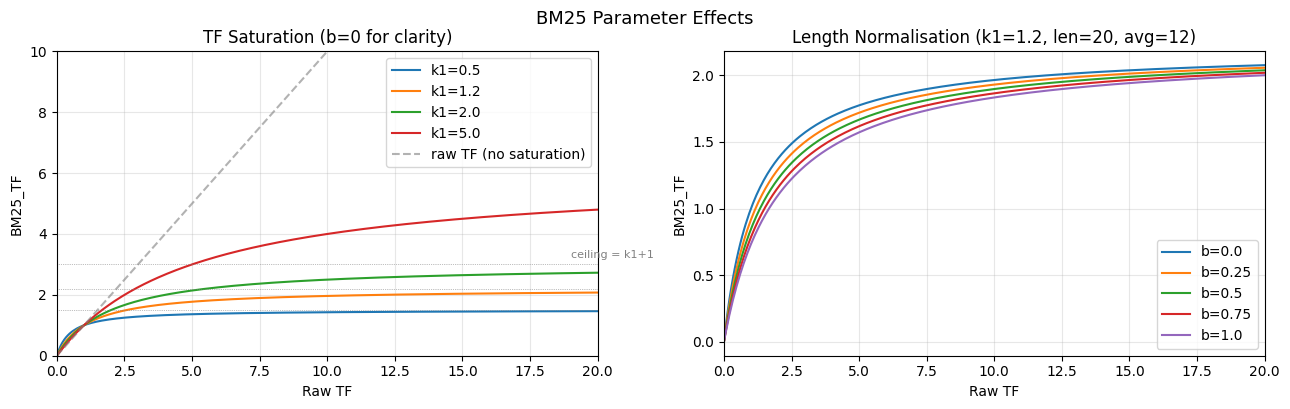

Key insights:
  k1 sets the TF ceiling: BM25_TF -> k1+1 as tf -> infinity
  b=0: no length normalisation; b=1: full normalisation by length
  Default k1=1.2, b=0.75 chosen empirically on TREC benchmarks


In [16]:
# TF saturation and length normalisation plots (Theory §§5.2-5.3)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

tf_range = np.linspace(0, 20, 300)

# Left: TF saturation for different k1
ax = axes[0]
for k1 in [0.5, 1.2, 2.0, 5.0]:
    bm25_tf = tf_range * (k1 + 1) / (tf_range + k1)  # b=0 for isolation
    ax.plot(tf_range, bm25_tf, label=f'k1={k1}')
ax.plot(tf_range, tf_range, '--', color='gray', alpha=0.6, label='raw TF (no saturation)')
ax.set_title('TF Saturation (b=0 for clarity)')
ax.set_xlabel('Raw TF')
ax.set_ylabel('BM25_TF')
ax.set_ylim(0, 10)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 20)

# Annotate ceiling
for k1 in [0.5, 1.2, 2.0]:
    ax.axhline(y=k1+1, color='gray', lw=0.5, linestyle=':')
ax.annotate('ceiling = k1+1', xy=(19, 3.2), fontsize=8, color='gray')

# Right: length normalisation for different b
ax = axes[1]
doc_len, avg_len = 20, 12
for b_val in [0.0, 0.25, 0.5, 0.75, 1.0]:
    k1 = 1.2
    norm = 1 - b_val + b_val * doc_len / avg_len
    bm25_tf = tf_range * (k1 + 1) / (tf_range + k1 * norm)
    ax.plot(tf_range, bm25_tf, label=f'b={b_val}')
ax.set_title(f'Length Normalisation (k1=1.2, len={doc_len}, avg={avg_len})')
ax.set_xlabel('Raw TF')
ax.set_ylabel('BM25_TF')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 20)

plt.tight_layout()
plt.suptitle('BM25 Parameter Effects', y=1.01, fontsize=13)
plt.show()

print("Key insights:")
print("  k1 sets the TF ceiling: BM25_TF -> k1+1 as tf -> infinity")
print("  b=0: no length normalisation; b=1: full normalisation by length")
print(f"  Default k1=1.2, b=0.75 chosen empirically on TREC benchmarks")

In [17]:
# BM25 implementation (Week 3 Lab cells 36-42 — all stubs filled)
k_1 = 1.2
b   = 0.75

# Document lengths (Week 3 Lab stub: dls, avgdl)
dls   = np.array([len(TOKENS[i]) for i in range(N)])
avgdl = float(dls.mean())

print(f"Document length stats:")
print(f"  min={dls.min()}, max={dls.max()}, avg={avgdl:.1f}")

# Inverted index from preprocessed tokens
BM25_INDEX = defaultdict(lambda: defaultdict(int))
for i, toks in enumerate(TOKENS):
    for t in toks:
        BM25_INDEX[t][i] += 1
BM25_DF = {t: len(BM25_INDEX[t]) for t in BM25_INDEX}

def bm25_score_doc(query_terms, doc_idx):
    score = 0.0
    dl = float(dls[doc_idx])
    for t in query_terms:
        if t not in BM25_INDEX:
            continue
        tf_t  = BM25_INDEX[t].get(doc_idx, 0)
        df_t  = BM25_DF[t]
        # IDF: RSJ formula with 0.5 smoothing (Week 3 Lab stub for idfs)
        idf_t = math.log((N - df_t + 0.5) / (df_t + 0.5) + 1)
        # BM25 TF: saturation + length norm (Week 3 Lab stub for denominator)
        numerator   = tf_t * (k_1 + 1)
        denominator = tf_t + k_1 * (1 - b + b * dl / avgdl)
        score += idf_t * (numerator / denominator)
    return score

def bm25_rank(query_terms, top_k=None):
    scores = sorted([(bm25_score_doc(query_terms, i), i) for i in range(N)], reverse=True)
    return scores[:top_k] if top_k else scores

# Run BM25
query_bm25 = ['sanction', 'debarment']
top10 = bm25_rank(query_bm25, top_k=10)
print(f"\nBM25 — Query: {query_bm25}")
print(f"{'Rank':<5} {'BM25':>8}  Caption")
print("-" * 65)
for rank, (score, idx) in enumerate(top10, 1):
    if score > 0:
        print(f"{rank:<5} {score:>8.4f}  {DOCS[idx]['caption'][:55]}")

Document length stats:
  min=3, max=380, avg=25.7

BM25 — Query: ['sanction', 'debarment']
Rank      BM25  Caption
-----------------------------------------------------------------
1       2.0363  Star Dragon Corporation Limited
2       1.8671  Sun Science International Co., Limited
3       1.7576  Angel Daniel Balestrini Jaramillo
4       1.6915  Albahr Alaahmar Energy FZE
5       1.6602  Ekvik Limited Liability Company
6       1.5460  LOLA LOLITA 1110, S. DE R.L. DE C.V.
7       1.4465  Nasser Al Sheikh Ali
8       1.4236  Michael Kuajien
9       1.3388  Golden Luxury Jewellery Trading L.L.C
10      1.2146  Zviad TSEKVAVA


In [18]:
# TF-IDF VSM vs BM25 side-by-side
query_cmp = ['sanction', 'debarment']

tfidf_res = [(idx, score) for idx, score in tfidf_vsm(query_cmp, top_k=N) if score > 0]
bm25_res  = [(idx, score) for score, idx in bm25_rank(query_cmp, top_k=N)  if score > 0]

tfidf_ranks = {idx: (r+1, s) for r, (idx, s) in enumerate(tfidf_res)}
bm25_ranks  = {idx: (r+1, s) for r, (idx, s) in enumerate(bm25_res)}

print(f"TF-IDF VSM vs BM25 — Query: {query_cmp}\n")
print(f"{'BM25 rk':>8} {'BM25 sc':>9} {'TF-IDF rk':>10} {'TF-IDF sc':>10}  Caption")
print("-" * 75)

for score, idx in bm25_rank(query_cmp, top_k=12):
    if score <= 0: break
    br, bs = bm25_ranks.get(idx, (99, 0.0))
    tr, ts = tfidf_ranks.get(idx, (99, 0.0))
    print(f"{br:>8} {bs:>9.4f} {tr:>10} {ts:>10.4f}  {DOCS[idx]['caption'][:40]}")

print("\nBM25 advantages over TF-IDF:")
print("  - TF saturation: the 5th mention of a term is worth less than the 1st")
print("  - Length norm built into the score, not applied after via cosine")
print("  - Grounded in probability theory (BIM -> RSJ)")

TF-IDF VSM vs BM25 — Query: ['sanction', 'debarment']

 BM25 rk   BM25 sc  TF-IDF rk  TF-IDF sc  Caption
---------------------------------------------------------------------------
       1    2.0363          1     0.1006  Star Dragon Corporation Limited
       2    1.8671          9     0.0619  Sun Science International Co., Limited
       3    1.7576         42     0.0330  Angel Daniel Balestrini Jaramillo
       4    1.6915         25     0.0454  Albahr Alaahmar Energy FZE
       5    1.6602         13     0.0588  Ekvik Limited Liability Company
       6    1.5460         21     0.0490  LOLA LOLITA 1110, S. DE R.L. DE C.V.
       7    1.4465         52     0.0272  Nasser Al Sheikh Ali
       8    1.4236         68     0.0180  Michael Kuajien
       9    1.3388         46     0.0318  Golden Luxury Jewellery Trading L.L.C
      10    1.2146          8     0.0676  Zviad TSEKVAVA
      11    1.2146          7     0.0676  Khalid SBAA
      12    1.1963         80     0.0122  BAHRAMI ALI 

### BM25 By Hand — Worked Example (Theory §5.7)

**Collection** (3 documents), **query**: "russian sanctions"

| ID | Document | tf(russian) | tf(sanction) | Length |
|----|----------|-------------|--------------|--------|
| D1 | "Russian oligarch evading sanctions. Linked to energy." | 1 | 2 | 7 |
| D2 | "Forced labour supply chain. Linked to Xinjiang." | 0 | 1 | 7 |
| D3 | "North Korean vessel transporting oil. UN sanctions." | 0 | 2 | 7 |

**Parameters:** \(k_1=1.2,\;b=0.75,\;\bar{L}=7\)

**Step 1 — IDF (RSJ, \(N=3\)):**

$$\text{idf(russian)} = \log\left(\frac{3-1+0.5}{1+0.5}+1\right) = \log\left(\frac{2.5}{1.5}+1\right) = \log(2.667) \approx 0.981$$

$$\text{idf(sanction)} = \log\left(\frac{3-3+0.5}{3+0.5}+1\right) = \log\left(\frac{0.5}{3.5}+1\right) = \log(1.143) \approx 0.134$$

> Note: BM25 IDF here uses `log(... + 1)` to keep it non-negative even when df > N/2.

**Step 2 — BM25_TF for "russian" in D1** (tf=1, L=7, avg=7):

$$\text{BM25\_TF} = \frac{1 \cdot (1.2+1)}{1 + 1.2 \cdot \left(1-0.75+0.75\cdot\frac{7}{7}\right)} = \frac{2.2}{1+1.2} = \frac{2.2}{2.2} = 1.0$$

**Step 3 — BM25(D1, q) = 0.981 × 1.0 + 0.134 × BM25\_TF(sanction, D1)**

In [19]:
# Numerical verification of the by-hand example
mini_bm25_docs = [
    ['russian', 'oligarch', 'evad', 'sanction', 'link', 'energi', 'sector', 'sanction'],
    ['forc', 'labour', 'suppli', 'chain', 'link', 'xinjiang', 'sanction'],
    ['north', 'korean', 'vessel', 'transport', 'oil', 'sanction', 'sanction'],
]
mini_N     = len(mini_bm25_docs)
mini_dls   = np.array([len(d) for d in mini_bm25_docs])
mini_avgdl = float(mini_dls.mean())
mini_k1, mini_b = 1.2, 0.75

mini_query = ['russian', 'sanction']

print("BM25 by-hand verification:")
print(f"  k1={mini_k1}, b={mini_b}, avgdl={mini_avgdl:.1f}")
print()

all_terms = set(t for d in mini_bm25_docs for t in d)
mini_df = {t: sum(1 for d in mini_bm25_docs if t in d) for t in all_terms}

for i, doc in enumerate(mini_bm25_docs):
    total = 0.0
    print(f"D{i+1}: {doc}")
    for t in mini_query:
        tf_t  = doc.count(t)
        df_t  = mini_df.get(t, 0)
        idf_t = math.log((mini_N - df_t + 0.5) / (df_t + 0.5) + 1)
        dl    = mini_dls[i]
        denom = tf_t + mini_k1 * (1 - mini_b + mini_b * dl / mini_avgdl)
        bm_tf = tf_t * (mini_k1 + 1) / denom if denom > 0 else 0.0
        contrib = idf_t * bm_tf
        total  += contrib
        print(f"  t='{t}': tf={tf_t}, df={df_t}, idf={idf_t:.4f}, "
              f"BM25_TF={bm_tf:.4f}, contrib={contrib:.4f}")
    print(f"  => BM25(D{i+1}, q) = {total:.4f}")
    print()

BM25 by-hand verification:
  k1=1.2, b=0.75, avgdl=7.3

D1: ['russian', 'oligarch', 'evad', 'sanction', 'link', 'energi', 'sector', 'sanction']
  t='russian': tf=1, df=1, idf=0.9808, BM25_TF=0.9641, contrib=0.9457
  t='sanction': tf=2, df=3, idf=0.1335, BM25_TF=1.3407, contrib=0.1790
  => BM25(D1, q) = 1.1247

D2: ['forc', 'labour', 'suppli', 'chain', 'link', 'xinjiang', 'sanction']
  t='russian': tf=0, df=1, idf=0.9808, BM25_TF=0.0000, contrib=0.0000
  t='sanction': tf=1, df=3, idf=0.1335, BM25_TF=1.0189, contrib=0.1361
  => BM25(D2, q) = 0.1361

D3: ['north', 'korean', 'vessel', 'transport', 'oil', 'sanction', 'sanction']
  t='russian': tf=0, df=1, idf=0.9808, BM25_TF=0.0000, contrib=0.0000
  t='sanction': tf=2, df=3, idf=0.1335, BM25_TF=1.3928, contrib=0.1860
  => BM25(D3, q) = 0.1860



### Week 3 Lab — BM25 Discussion Questions (Q1–Q4)

**Q1: Why is it called "Best Match 25"?**

**A:** It was the 25th iteration of the probabilistic ranking framework built at the Okapi project
(City University London, 1990s) by Robertson, Sparck Jones and colleagues. Earlier versions tried
different term weighting and normalisation approaches; iteration 25 gave the best empirical
performance on TREC benchmarks, and the name stuck.

---

**Q2: Are the BM25 scores intuitively ordered? Anything surprising?**

**A:** In this corpus "sanction" appears in ~80% of entities, so its IDF is near zero — the score
is driven by *rarer* discriminating terms. An entity with a unique name ("Yatai") therefore ranks
highly for a "sanction + yatai" query even if it has fewer sanction mentions than another.
This is counterintuitive but correct: "sanction" adds almost no *new information* in a sanctions database.

---

**Q3: What is the role of \(k_1\)?**

**A:** \(k_1\) controls **TF saturation**:
- \(k_1 = 0.5\): TF saturates very quickly — the 3rd mention is nearly as good as the 10th
- \(k_1 = 2.0\): more linear — the 10th mention still adds meaningful score
- Default \(k_1 = 1.2\): at TF=5, the document scores ~2.4× a TF=1 document (not 5×)

BM25_TF ceiling = \(k_1 + 1\); no matter how many times a term appears, the score is bounded.

---

**Q4: What is the role of \(b\)?**

**A:** \(b\) controls **document length normalisation**:
- \(b = 0\): no normalisation — long documents always score higher (raw TF)
- \(b = 1\): full normalisation — scoring is purely density-based (term density = TF/length)
- Default \(b = 0.75\): partial normalisation — a longer document is somewhat penalised, reflecting
  the assumption that length carries content information (it's longer because it has more to say)

*See also:* [Elastic BM25 deep dive](https://www.elastic.co/blog/practical-bm25-part-2-the-bm25-algorithm-and-its-variables)

### BM25+ — Fixing the Lower Bound Problem (Theory §5.6)

**Problem:** In standard BM25, a document with \(\text{tf}_{t,d} = 0\) scores exactly 0 for term \(t\).
But a very long document with \(\text{tf}_{t,d} = 1\) may score *lower* than a short document with
\(\text{tf}_{t,d} = 1\) due to the length-normalisation denominator.
In extreme cases, a document with tf=0 can rank above one with tf=1.

**Fix (Lv & Zhai, 2011):** Add a constant \(\delta > 0\) (typically \(\delta = 1\)) to guarantee
a positive lower bound for any document containing the term:

$$\text{BM25+\_TF}(t, d) = \delta + \frac{\text{tf}_{t,d} \cdot (k_1 + 1)}{\text{tf}_{t,d} + k_1 \cdot \left(1-b+b\,\frac{L_d}{\bar{L}}\right)}$$

In [20]:
# BM25+ (Theory §5.6)
delta_plus = 1.0

def bm25plus_score_doc(query_terms, doc_idx):
    score = 0.0
    dl = float(dls[doc_idx])
    for t in query_terms:
        if t not in BM25_INDEX:
            continue
        tf_t  = BM25_INDEX[t].get(doc_idx, 0)
        df_t  = BM25_DF[t]
        idf_t = math.log((N - df_t + 0.5) / (df_t + 0.5) + 1)
        bm_tf = (delta_plus +
                 tf_t * (k_1 + 1) / (tf_t + k_1 * (1 - b + b * dl / avgdl)))
        score += idf_t * bm_tf
    return score

# Compare BM25 vs BM25+ on top results
query_plus = ['sanction', 'debarment']
bm25_d     = {idx: s for s, idx in bm25_rank(query_plus, top_k=N)}
plus_res   = sorted(
    [(bm25plus_score_doc(query_plus, i), i) for i in range(N)],
    reverse=True
)[:10]

print(f"BM25 vs BM25+ — Query: {query_plus}  (delta={delta_plus})")
print(f"\n{'Rank':<5} {'BM25':>8} {'BM25+':>8}  Caption")
print("-" * 68)
for rank, (score_plus, idx) in enumerate(plus_res, 1):
    if score_plus <= 0: break
    print(f"{rank:<5} {bm25_d.get(idx,0):>8.4f} {score_plus:>8.4f}  {DOCS[idx]['caption'][:45]}")

print("\nBM25+ scores are uniformly higher (by delta * idf_sum)")
print("but relative ranking may shift for documents with borderline tf=1 terms.")

BM25 vs BM25+ — Query: ['sanction', 'debarment']  (delta=1.0)

Rank      BM25    BM25+  Caption
--------------------------------------------------------------------
1       2.0363   3.4663  Star Dragon Corporation Limited
2       1.8671   3.2971  Sun Science International Co., Limited
3       1.7576   3.1876  Angel Daniel Balestrini Jaramillo
4       1.6915   3.1215  Albahr Alaahmar Energy FZE
5       1.6602   3.0902  Ekvik Limited Liability Company
6       1.5460   2.9760  LOLA LOLITA 1110, S. DE R.L. DE C.V.
7       1.4465   2.8765  Nasser Al Sheikh Ali
8       1.4236   2.8536  Michael Kuajien
9       1.3388   2.7688  Golden Luxury Jewellery Trading L.L.C
10      1.2146   2.6446  Zviad TSEKVAVA

BM25+ scores are uniformly higher (by delta * idf_sum)
but relative ranking may shift for documents with borderline tf=1 terms.


---
## Section 5: BM25F — Multi-Field Retrieval

Standard BM25 treats every document as a single flat text blob.
**BM25F** (Robertson et al., 2004) recognises that real documents have **multiple fields**
with different importance levels — and should be searched differently.

*(Theory §6)*

### Motivation

OpenSanctions entities have three natural fields:

| Field | Example content | Importance for search |
|-------|----------------|----------------------|
| `name` | "Myanmar Yatai International Holding Group" | Very high — exact name queries |
| `description` | "Linked to construction of buildings in SEZ..." | Medium — topic/context queries |
| `topics` | `["sanction", "debarment"]` | High — categorical queries |

**Problem with flat BM25:** an entity with a long description has its name tokens diluted.
A one-word name "Yatai" in 500 tokens of description has TF = 1/500 = 0.002.
A flat BM25 would under-score this entity for the query "Yatai sanctions".

### BM25F Formula

Compute a **pseudo-TF** as a weighted sum across fields — each field length-normalised independently:

$$\tilde{\text{tf}}_{t,d} = \sum_{f} w_f \cdot \frac{\text{tf}_{t,f}}{(1-b_f)+b_f\,\frac{L_{d,f}}{\bar{L}_f}}$$

Then apply standard BM25 scoring using this pseudo-TF:

$$\text{BM25F}(d, q) = \sum_{t \in q} \text{IDF}(t) \cdot \frac{\tilde{\text{tf}}_{t,d}\cdot(k_1+1)}{\tilde{\text{tf}}_{t,d}+k_1}$$

In [21]:
# Load raw OpenSanctions data for multi-field extraction
def _norm_tok(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    return [t for t in text.split() if len(t) > 1]

_raw_path  = _find_file("data", "raw_data", "sample_targets.json")
_raw_docs  = [json.loads(l) for l in _raw_path.open(encoding="utf-8")]
_raw_by_id = {d['id']: d for d in _raw_docs}

FIELD_DOCS = []
for doc in DOCS:
    raw   = _raw_by_id.get(doc['doc_id'], {})
    props = raw.get('properties', {})

    name_toks = []
    for v in (props.get('name', []) + props.get('alias', []) +
               props.get('previousName', [])):
        if isinstance(v, str): name_toks.extend(_norm_tok(v))

    desc_toks = []
    for v in (props.get('notes', []) + props.get('description', []) +
               props.get('summary', [])):
        if isinstance(v, str): desc_toks.extend(_norm_tok(v))

    topic_toks = []
    for v in props.get('topics', []):
        if isinstance(v, str):
            cleaned = _norm_tok(v)
            topic_toks.extend(cleaned)

    FIELD_DOCS.append({
        'doc_id':  doc['doc_id'],
        'caption': doc['caption'],
        'fields':  {'name': name_toks, 'desc': desc_toks, 'topics': topic_toks},
    })

# Stats
for fn in ['name', 'desc', 'topics']:
    populated = [d for d in FIELD_DOCS if d['fields'][fn]]
    if populated:
        avg = np.mean([len(d['fields'][fn]) for d in populated])
        print(f"  {fn:<8}: {len(populated):3d} / {N} docs populated  avg_len={avg:.1f} tokens")

# Sample
s = FIELD_DOCS[0]
print(f"\nSample: {s['caption'][:50]}")
for fn, fv in s['fields'].items():
    print(f"  {fn}: {fv[:6]}")

  name    : 100 / 100 docs populated  avg_len=14.3 tokens
  desc    :  21 / 100 docs populated  avg_len=57.4 tokens
  topics  : 100 / 100 docs populated  avg_len=1.7 tokens

Sample: Myanmar Yatai International Holding Group Co., LTD
  name: ['yatai', 'new', 'city', 'myanmar', 'yatai', 'international']
  desc: ['also', 'shwe', 'kokko', 'special', 'economic', 'zone']
  topics: ['sanction', 'debarment']


In [22]:
# BM25F parameters
FIELD_WEIGHTS = {'name': 3.0, 'desc': 1.0, 'topics': 2.0}
FIELD_B       = {'name': 0.5, 'desc': 0.75, 'topics': 0.0}
K1_F          = 1.2

# Average field lengths (over docs with non-empty field)
avg_fl = {}
for fn in ['name', 'desc', 'topics']:
    lengths = [len(d['fields'][fn]) for d in FIELD_DOCS if d['fields'][fn]]
    avg_fl[fn] = float(np.mean(lengths)) if lengths else 1.0
print("Average field lengths:", {k: round(v,1) for k,v in avg_fl.items()})

# Per-field inverted indices
FIDX = {}
for fn in ['name', 'desc', 'topics']:
    idx = defaultdict(lambda: defaultdict(int))
    for i, doc in enumerate(FIELD_DOCS):
        for term in doc['fields'][fn]:
            idx[term][i] += 1
    FIDX[fn] = idx

def bm25f_score_doc(query_terms, doc_idx):
    score = 0.0
    for t in query_terms:
        df_t  = BM25_DF.get(t, 0)
        idf_t = math.log((N - df_t + 0.5) / (df_t + 0.5) + 1)

        pseudo_tf = 0.0
        for fn, w_f in FIELD_WEIGHTS.items():
            tf_f  = FIDX[fn][t].get(doc_idx, 0)
            if tf_f == 0:
                continue
            b_f   = FIELD_B[fn]
            l_f   = len(FIELD_DOCS[doc_idx]['fields'][fn])
            norm  = (1 - b_f) + b_f * l_f / avg_fl[fn]
            pseudo_tf += w_f * tf_f / norm

        bm25f_tf = pseudo_tf * (K1_F + 1) / (pseudo_tf + K1_F) if pseudo_tf > 0 else 0.0
        score   += idf_t * bm25f_tf
    return score

def bm25f_rank(query_terms, top_k=None):
    scores = sorted([(bm25f_score_doc(query_terms, i), i)
                     for i in range(N)], reverse=True)
    return scores[:top_k] if top_k else scores

# Compare BM25 vs BM25F
query_f   = ['sanction', 'debarment']
top_f     = bm25f_rank(query_f, top_k=10)
bm25_dict = {idx: s for s, idx in bm25_rank(query_f, top_k=N)}

print(f"\nBM25 vs BM25F — Query: {query_f}")
print(f"  Field weights: {FIELD_WEIGHTS}")
print()
print(f"{'Rank':<5} {'BM25F':>8} {'BM25':>8}  Caption")
print("-" * 68)
for rank, (score, idx) in enumerate(top_f, 1):
    if score <= 0: break
    print(f"{rank:<5} {score:>8.4f} {bm25_dict.get(idx,0):>8.4f}  "
          f"{FIELD_DOCS[idx]['caption'][:45]}")

Average field lengths: {'name': 14.3, 'desc': 57.4, 'topics': 1.7}

BM25 vs BM25F — Query: ['sanction', 'debarment']
  Field weights: {'name': 3.0, 'desc': 1.0, 'topics': 2.0}

Rank     BM25F     BM25  Caption
--------------------------------------------------------------------
1       1.9662   1.0558  TAWU Mechanical Engineering and Trading Compa
2       1.9662   1.7576  Angel Daniel Balestrini Jaramillo
3       1.9662   1.0133  Nurkez
4       1.9662   1.5460  LOLA LOLITA 1110, S. DE R.L. DE C.V.
5       1.9662   1.8671  Sun Science International Co., Limited
6       1.9662   1.6915  Albahr Alaahmar Energy FZE
7       1.9662   1.4465  Nasser Al Sheikh Ali
8       1.9662   0.7807  USAMAH 'ABD-AL-WAHID AL-JAZA'IRI BELKACEM
9       1.9662   1.3388  Golden Luxury Jewellery Trading L.L.C
10      1.9662   1.1963  BAHRAMI ALI SHAYESTEH


In [23]:
# Effect of field weights on ranking — name-specific query
print("Field weight sensitivity study")
print("Query: a name-specific token + 'sanction'")
print()

# Find a token that appears only in the name field
name_only_terms = [t for t in FIDX['name']
                   if FIDX['name'][t] and not FIDX['desc'][t] and not FIDX['topics'][t]]
name_only_terms.sort(key=lambda t: -len(FIDX['name'][t]))
demo_term = name_only_terms[0] if name_only_terms else 'yatai'
query_fw  = [demo_term, 'sanction']
print(f"Demo term '{demo_term}' appears in name field of "
      f"{len(FIDX['name'][demo_term])} docs, desc field of {len(FIDX['desc'][demo_term])} docs")
print()

orig_weights = FIELD_WEIGHTS.copy()
for name_w in [0.5, 1.0, 3.0, 8.0]:
    FIELD_WEIGHTS['name'] = name_w
    top3 = bm25f_rank(query_fw, top_k=3)
    caps = [FIELD_DOCS[idx]['caption'][:28] for _, idx in top3]
    print(f"  name_w={name_w:<4}: {caps}")
FIELD_WEIGHTS.update(orig_weights)

Field weight sensitivity study
Query: a name-specific token + 'sanction'

Demo term 'общество' appears in name field of 13 docs, desc field of 0 docs

  name_w=0.5 : ['Акціонерне товариство "Елект', 'Акционерное общество "Спорт-', 'Товариство з обмеженою відпо']
  name_w=1.0 : ['Акціонерне товариство "Елект', 'Акционерное общество "Спорт-', 'Товариство з обмеженою відпо']
  name_w=3.0 : ['Акціонерне товариство "Елект', 'Акционерное общество "Спорт-', 'Товариство з обмеженою відпо']
  name_w=8.0 : ['Акціонерне товариство "Елект', 'Акционерное общество "Спорт-', 'Товариство з обмеженою відпо']


---
## Section 6: Full Model Comparison

We now run **all five models** on the same queries and compare results side by side.

| Model | Ranking method | Key strengths |
|-------|---------------|--------------|
| Boolean | Set algebra | Exact control; no false positives |
| VSM (binary) | Cosine of binary vectors | Simple; interpretable |
| TF-IDF | Cosine of TF-IDF vectors | Term importance weighting |
| BM25 | Probabilistic | TF saturation + length norm; industry standard |
| BM25F | Multi-field BM25 | Field-specific weights and normalisation |

In [24]:
def run_all_models(query_terms, top_k=6):
    print(f"{'='*70}")
    print(f"Query: {query_terms}")
    print(f"{'='*70}")

    # Boolean AND
    bool_res = boolean_AND(query_terms, term_occurrence)
    print(f"\nBoolean AND -> {len(bool_res)} results:")
    for idx in bool_res[:top_k]:
        print(f"  [{idx:3d}] {DOCS[idx]['caption'][:55]}")
    if len(bool_res) > top_k:
        print(f"  ... ({len(bool_res)-top_k} more)")
    print()

    # VSM binary
    vsm_res = [(s, i) for s, i in vector_space_model(term_doc_mat_np, query_terms)
               if s > 0][:top_k]
    # TF-IDF
    tfi_res = [(s, i) for i, s in tfidf_vsm(query_terms, top_k=N) if s > 0][:top_k]
    # BM25
    bm_res  = [(s, i) for s, i in bm25_rank(query_terms, top_k=N)  if s > 0][:top_k]
    # BM25F
    bmf_res = [(s, i) for s, i in bm25f_rank(query_terms, top_k=N) if s > 0][:top_k]

    print(f"{'Model':<12} {'Rk':<4} {'Score':>8}  Caption")
    print("-" * 70)
    for name, ranked in [("VSM", vsm_res), ("TF-IDF", tfi_res),
                          ("BM25", bm_res), ("BM25F", bmf_res)]:
        for rank, (score, idx) in enumerate(ranked, 1):
            print(f"{name:<12} {rank:<4} {score:>8.4f}  {DOCS[idx]['caption'][:40]}")
        print()

run_all_models(['sanction', 'debarment'])
run_all_models(['wanted', 'crime'])
run_all_models(['vessel'])

Query: ['sanction', 'debarment']

Boolean AND -> 17 results:
  [  0] Myanmar Yatai International Holding Group Co., LTD.
  [  9] Michael Kuajien
  [ 13] Limited Liability Company Specialized Developer Alabuga
  [ 15] Digital Marketing Awards FZ LLC
  [ 21] Ekvik Limited Liability Company
  [ 37] Star Dragon Corporation Limited
  ... (11 more)

Model        Rk      Score  Caption
----------------------------------------------------------------------
VSM          1      0.5774  Angel Daniel Balestrini Jaramillo
VSM          2      0.5345  LOLA LOLITA 1110, S. DE R.L. DE C.V.
VSM          3      0.5345  BAHRAMI ALI SHAYESTEH
VSM          4      0.5345  Star Dragon Corporation Limited
VSM          5      0.5345  Michael Kuajien
VSM          6      0.5000  Sun Science International Co., Limited

TF-IDF       1      0.1006  Star Dragon Corporation Limited
TF-IDF       2      0.0772  KATHLEEN J KING
TF-IDF       3      0.0717  AROB KOLNYANG
TF-IDF       4      0.0717  Carol Parker
TF-IDF     

In [25]:
# Compact rank-comparison DataFrame (BM25 order, all model ranks shown)
query_final = ['sanction', 'debarment']

vsm_r  = {i: r+1 for r, (s,i) in enumerate(vector_space_model(term_doc_mat_np, query_final)) if s>0}
tfi_r  = {i: r+1 for r, (i,s) in enumerate(tfidf_vsm(query_final, top_k=N))  if s>0}
bm_r   = {i: r+1 for r, (s,i) in enumerate(bm25_rank(query_final, top_k=N))  if s>0}
bmf_r  = {i: r+1 for r, (s,i) in enumerate(bm25f_rank(query_final, top_k=N)) if s>0}

rows = []
for _, idx in bm25_rank(query_final, top_k=12):
    if bm_r.get(idx, 999) > 12: continue
    rows.append({
        'Caption':     DOCS[idx]['caption'][:38],
        'Schema':      DOCS[idx]['schema'],
        'VSM rk':      vsm_r.get(idx, '-'),
        'TF-IDF rk':   tfi_r.get(idx, '-'),
        'BM25 rk':     bm_r.get(idx,  '-'),
        'BM25F rk':    bmf_r.get(idx, '-'),
    })

df_cmp = pd.DataFrame(rows)
print(f"Rank comparison — Query: {query_final}\n")
print(df_cmp.to_string(index=False))

Rank comparison — Query: ['sanction', 'debarment']

                               Caption       Schema  VSM rk  TF-IDF rk  BM25 rk  BM25F rk
       Star Dragon Corporation Limited      Company       4          1        1        12
Sun Science International Co., Limited      Company       6          9        2         5
     Angel Daniel Balestrini Jaramillo       Person       1         42        3         2
            Albahr Alaahmar Energy FZE      Company       7         25        4         6
       Ekvik Limited Liability Company      Company      19         13        5        13
  LOLA LOLITA 1110, S. DE R.L. DE C.V. Organization       2         21        6         4
                  Nasser Al Sheikh Ali       Person      20         52        7         7
                       Michael Kuajien       Person       5         68        8        16
 Golden Luxury Jewellery Trading L.L.C      Company      21         46        9         9
                        Zviad TSEKVAVA       Per

---
## Summary — When to Use Which Model

*(Theory §8.1)*

| Model | Use when | Avoid when |
|-------|----------|------------|
| **Boolean** | Exact compliance filtering; legal queries; expert users | End-user search; need ranking |
| **VSM (binary)** | Teaching; quick prototype; tiny corpus | Large corpus; long documents |
| **TF-IDF** | General-purpose baseline; medium corpora | Very long documents; production |
| **BM25** | Production search; any corpus; Elasticsearch default | Documents with strongly varying field importance |
| **BM25F** | Structured documents (name / body / tags); entity search | Single-field flat text |

### The Progression

```
Boolean         → VSM           → TF-IDF         → BM25               → BM25F
set membership    cosine score    term importance   TF saturation         multi-field
no ranking        ranked          + IDF weighting   + length norm         + field weights
                                                    (probabilistic)       (per-field norm)
```

### Connection to the OpenSanctions Project

**Phase 5** of the project builds a BM25 index over **1.24 million real entities** using `rank-bm25`.
The BM25F pattern you implemented here (separate name / description / topics fields with different weights)
is the architecture for the multi-field retrieval extension in Phase 6.

### What's Next

The Module 2 `theory.md` covers **Language Models** (§7) — Jelinek-Mercer and Dirichlet smoothing —
which offer a principled alternative to BM25 and asymptotically connect to it.
These are the foundation for **neural retrieval** (dense vectors, bi-encoders) covered in Module 3.